In [1]:
#!/usr/bin/env python3
"""
Multi-compartmental nRT cell M_type example

File: nRTm.py

Copyright 2023 NeuroML contributors
Authors: Padraig Gleeson, Ankur Sinha
Modified for nRTm by Hua Cheng
"""

from pyneuroml.analysis import generate_current_vs_frequency_curve

from neuroml import NeuroMLDocument
from neuroml.utils import component_factory
from pyneuroml import pynml
from pyneuroml.lems import LEMSSimulation
from pyneuroml.plot.PlotMorphology import plot_2D
import numpy as np
import math
from neuroml import Cell, Segment, SegmentGroup, Point3DWithDiam,NeuroMLDocument
from neuroml.utils import component_factory

INFO:numexpr.utils:NumExpr defaulting to 16 threads.


In [2]:
def create_nRTm_cell():
    nml_cell_doc = NeuroMLDocument(id="nRTm_cell")
    cell = nml_cell_doc.add(Cell,id="nRTm", neuro_lex_id="NLXCELL:091206")  # type neuroml.Cell
    cell.summary()
    cell.info(show_contents=True)
    cell.morphology.info(show_contents=True)

    cell.add_unbranched_segment_group("soma_0")
    diam_soma = 18.6  # Diameter of the soma
    diam_axon = 1.6  # Diameter of the axon
    diam_dendrite = 2.12  # Diameter of the dendrites
    soma_0 = cell.add_segment(
        prox=[0.0, 0.0, 0.0, diam_soma],
        dist=[0.0, 15.0, 0.0, diam_soma],
        name="Seg0_soma_0",
        group_id="soma_0",
        seg_type="soma"
    )
    soma_1 = cell.add_segment(
        prox=None,
        dist=[-0.0, 30, 0.0, diam_soma],
        name="Seg1_soma_0",
        parent=soma_0,
        group_id="soma_0",
        seg_type="soma"
    )
    # Add axon segments
    cell.add_unbranched_segments(
        [
            [0.0, 15.0, 0.0,diam_axon],
            [0.0, 0.0, 0.0, diam_axon],
            [-0.0,-25.0,0.0,diam_axon],
        ],
        parent=soma_0,
        fraction_along=0.0,
        group_id="axon_0",
        seg_type="axon"
    )

    cell.add_unbranched_segments(
        [
            [0.0,-25.0,0.0,diam_axon-0.2],
            [-0.0,-50.0,0.0,diam_axon-0.2],
            [-0.0,-75.0,0.0,diam_axon-0.2],
        ],
        parent=soma_1,
        fraction_along=0.0,
        group_id="axon_1",
        seg_type="axon"
    )

    cell.add_unbranched_segments(
        [
            [0.0,-75.0,0.0,diam_axon-0.3],
            [-0.0,-100.0,0.0,diam_axon-0.3],
            [-9.7354555,-123.02701,0.0,diam_axon-0.3],
        ],
        parent=soma_1,
        group_id="axon_2",
        seg_type="axon"
    )

    cell.add_unbranched_segments(
        [
            [-9.7354555,-123.02701,0.0,diam_axon-0.4],
            [19.470907,-146.053,0.0,diam_axon-0.4],
            [29.206408,-169.08,0.0,diam_axon-0.4],
        ],
        parent=soma_1,
        group_id="axon_3",
        seg_type="axon"
    )

    cell.add_unbranched_segments(
        [
            [0.0,-75.0,0.0,diam_axon-0.5],
            [0.0,-100.0,0.0,diam_axon-0.5],
            [-9.735475,-123.02701,0.0,diam_axon-0.5],
        ],
        parent=soma_1,
        group_id="axon_4",
        seg_type="axon"
    )

    cell.add_unbranched_segments(
        [
            [-9.735475,-123.02701,0.0,diam_axon-0.6],
            [-19.470892,-146.053,0.0,diam_axon-0.6],
            [-29.206392,-169.08,0.0,diam_axon-0.6],
        ],
        parent=soma_1,
        group_id="axon_5",
        seg_type="axon"
    )

    num_dendrites = 104
    radius1 = 50
    radius2 = 200
    y_base = 30.0
    diam_dendrite = 1.46

    # Create hierarchical dendritic structure with 5 layers, similar to nRTc
    dendrite_groups = {}  # Store all dendrite groups by ID for referencing
    
    # Layer 1: 26 primary dendrites attached to soma_1
    layer1_count = 16
    for i in range(layer1_count):
        angle = 2 * math.pi * i / layer1_count
        x1 = radius1 * math.cos(angle)
        z1 = radius1 * math.sin(angle)
        x2 = radius2 * math.cos(angle)
        z2 = radius2 * math.sin(angle)

        dend_coords = [
            [0.0, y_base, 0.0, diam_dendrite],
            [x1, y_base + 0.5 * radius1, z1, diam_dendrite],
            [x2, y_base + radius1, z2, diam_dendrite],
        ]
        group = cell.add_unbranched_segments(
            dend_coords,
            parent=soma_1,
            fraction_along=1.0,
            group_id=f"primary_dend_{i}",
            seg_type="dendrite"
        )
        dendrite_groups[f"primary_dend_{i}"] = group

    # Layer 2: 22 secondary dendrites attached to primary dendrites
    layer2_count = 32
    for i in range(layer2_count):
        # Attach to primary dendrites in a distributed manner
        parent_idx = i * layer1_count // layer2_count
        parent_group = dendrite_groups[f"primary_dend_{parent_idx}"]
        last_segment_id = parent_group.members[-1].segments
        last_segment = cell.get_segment(last_segment_id)
        
        # Get the distal point of the parent segment as the new origin
        parent_x = last_segment.distal.x
        parent_y = last_segment.distal.y
        parent_z = last_segment.distal.z
        
        # Add a subtle twist to the child dendrites
        angle = 2 * math.pi * i / layer2_count + math.pi/36  # Much reduced twist
        twist_angle = (i * 0.03) % (2 * math.pi)  # Much smaller twist
        # Make secondary dendrites shorter than primary ones
        x1 = parent_x + radius1 * math.cos(angle) * 0.7
        z1 = parent_z + radius1 * math.sin(angle) * 0.7
        x2 = parent_x + radius2 * math.cos(angle + twist_angle) * 0.7
        z2 = parent_z + radius2 * math.sin(angle + twist_angle) * 0.7

        dend_coords = [
            [parent_x, parent_y, parent_z, diam_dendrite],
            [x1, parent_y + 0.4 * radius1 * 0.7, z1, diam_dendrite],
            [x2, parent_y + 0.8 * radius1 * 0.7, z2, diam_dendrite],
        ]
        group = cell.add_unbranched_segments(
            dend_coords,
            parent=last_segment,
            fraction_along=1.0,
            group_id=f"secondary_dend_{i}",
            seg_type="dendrite"
        )
        dendrite_groups[f"secondary_dend_{i}"] = group

    # Layer 3: 22 tertiary dendrites attached to secondary dendrites
    layer3_count = 32
    for i in range(layer3_count):
        # Attach to secondary dendrites in a distributed manner
        parent_idx = i * layer2_count // layer3_count
        parent_group = dendrite_groups[f"secondary_dend_{parent_idx}"]
        last_segment_id = parent_group.members[-1].segments
        last_segment = cell.get_segment(last_segment_id)
        
        # Get the distal point of the parent segment as the new origin
        parent_x = last_segment.distal.x
        parent_y = last_segment.distal.y
        parent_z = last_segment.distal.z
        
        # Add a subtle twist to the child dendrites
        angle = 2 * math.pi * i / layer3_count + math.pi/54  # Even smaller base twist
        twist_angle = (i * 0.02) % (2 * math.pi)  # Reduced twist
        # Make tertiary dendrites shorter than secondary ones
        x1 = parent_x + radius1 * math.cos(angle) * 0.5
        z1 = parent_z + radius1 * math.sin(angle) * 0.5
        x2 = parent_x + radius2 * math.cos(angle + twist_angle) * 0.5
        z2 = parent_z + radius2 * math.sin(angle + twist_angle) * 0.5

        dend_coords = [
            [parent_x, parent_y, parent_z, diam_dendrite],
            [x1, parent_y + 0.3 * radius1 * 0.5, z1, diam_dendrite],
            [x2, parent_y + 0.6 * radius1 * 0.5, z2, diam_dendrite],
        ]
        group = cell.add_unbranched_segments(
            dend_coords,
            parent=last_segment,
            fraction_along=1.0,
            group_id=f"tertiary_dend_{i}",
            seg_type="dendrite"
        )
        dendrite_groups[f"tertiary_dend_{i}"] = group

    # Layer 4: 22 quaternary dendrites attached to tertiary dendrites
    layer4_count = 16
    for i in range(layer4_count):
        # Attach to tertiary dendrites in a distributed manner
        parent_idx = i * layer3_count // layer4_count
        parent_group = dendrite_groups[f"tertiary_dend_{parent_idx}"]
        last_segment_id = parent_group.members[-1].segments
        last_segment = cell.get_segment(last_segment_id)
        
        # Get the distal point of the parent segment as the new origin
        parent_x = last_segment.distal.x
        parent_y = last_segment.distal.y
        parent_z = last_segment.distal.z
        
        # Add a subtle twist to the child dendrites
        angle = 2 * math.pi * i / layer4_count + math.pi/72  # Very small base twist
        twist_angle = (i * 0.01) % (2 * math.pi)  # Minimal twist
        # Make quaternary dendrites shorter than tertiary ones
        x1 = parent_x + radius1 * math.cos(angle) * 0.3
        z1 = parent_z + radius1 * math.sin(angle) * 0.3
        x2 = parent_x + radius2 * math.cos(angle + twist_angle) * 0.3
        z2 = parent_z + radius2 * math.sin(angle + twist_angle) * 0.3

        dend_coords = [
            [parent_x, parent_y, parent_z, diam_dendrite],
            [x1, parent_y + 0.2 * radius1 * 0.3, z1, diam_dendrite],
            [x2, parent_y + 0.4 * radius1 * 0.3, z2, diam_dendrite],
        ]
        group = cell.add_unbranched_segments(
            dend_coords,
            parent=last_segment,
            fraction_along=1.0,
            group_id=f"quaternary_dend_{i}",
            seg_type="dendrite"
        )
        dendrite_groups[f"quaternary_dend_{i}"] = group

    # Layer 5: 12 quinary dendrites attached to quaternary dendrites
    layer5_count = 8
    for i in range(layer5_count):
        # Attach to quaternary dendrites in a distributed manner
        parent_idx = i * layer4_count // layer5_count
        parent_group = dendrite_groups[f"quaternary_dend_{parent_idx}"]
        last_segment_id = parent_group.members[-1].segments
        last_segment = cell.get_segment(last_segment_id)
        
        # Get the distal point of the parent segment as the new origin
        parent_x = last_segment.distal.x
        parent_y = last_segment.distal.y
        parent_z = last_segment.distal.z
        
        # Add a subtle twist to the child dendrites
        angle = 2 * math.pi * i / layer5_count + math.pi/108  # Minimal base twist
        twist_angle = (i * 0.005) % (2 * math.pi)  # Very small twist
        # Make quinary dendrites the shortest
        x1 = parent_x + radius1 * math.cos(angle) * 0.15
        z1 = parent_z + radius1 * math.sin(angle) * 0.15
        x2 = parent_x + radius2 * math.cos(angle + twist_angle) * 0.15
        z2 = parent_z + radius2 * math.sin(angle + twist_angle) * 0.15

        dend_coords = [
            [parent_x, parent_y, parent_z, diam_dendrite],
            [x1, parent_y + 0.15 * radius1 * 0.15, z1, diam_dendrite],
            [x2, parent_y + 0.3 * radius1 * 0.15, z2, diam_dendrite],
        ]
        group = cell.add_unbranched_segments(
            dend_coords,
            parent=last_segment,
            fraction_along=1.0,
            group_id=f"quinary_dend_{i}",
            seg_type="dendrite"
        )
        dendrite_groups[f"quinary_dend_{i}"] = group

    # Verify total count
    total_created = layer1_count + layer2_count + layer3_count + layer4_count + layer5_count
    print(f"Created dendritic tree with {total_created} dendrites (target: {num_dendrites})")

    # color groups for morphology plots
    den_seg_group = cell.get_segment_group("dendrite_group")
    den_seg_group.add("Property", tag="color", value="0.8 0 0")

    ax_seg_group = cell.get_segment_group("axon_group")
    ax_seg_group.add("Property", tag="color", value="0 0.8 0")

    soma_seg_group = cell.get_segment_group("soma_group")
    soma_seg_group.add("Property", tag="color", value="0 0 0.8")

    # Other cell properties
    cell.set_init_memb_potential("-88mV")
    cell.set_resistivity("0.15 kohm_cm")
    cell.set_specific_capacitance("1.3 uF_per_cm2")
    cell.set_spike_thresh("0.0 mV")
    

# channels
    # ar_soma_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="ar_soma",
                             cond_density="0.025 mS_per_cm2",
                             ion_channel="ar__m00",
                             ion_chan_def_file="ar__m00.channel.nml",
                             erev="-40.0 mV",
                             ion="ar",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="ar_dendrite",
                             cond_density="0.025 mS_per_cm2",
                             ion_channel="ar__m00",
                             ion_chan_def_file="ar__m00.channel.nml",
                             erev="-40.0 mV",
                             ion="ar",
                             group_id="dendrite_group")

    # cal_soma_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="cal_soma",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="cal",
                             ion_chan_def_file="cal.channel.nml",
                             erev="125.0 mV",
                             ion="ca",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="cal_dendrite",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="cal",
                             ion_chan_def_file="cal.channel.nml",
                             erev="125.0 mV",
                             ion="ca",
                             group_id="dendrite_group")
    # cat_a_soma_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="cat_a_soma",
                             cond_density="0.1 mS_per_cm2",
                             ion_channel="cat_a",
                             ion_chan_def_file="cat_a.channel.nml",
                             erev="125.0 mV",
                             ion="ca",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="cat_a_dendrite",
                             cond_density="0.1 mS_per_cm2",
                             ion_channel="cat_a",
                             ion_chan_def_file="cat_a.channel.nml",
                             erev="125.0 mV",
                             ion="ca",
                             group_id="dendrite_group")
    # k2_all
    cell.add_channel_density(nml_cell_doc,
                             cd_id="k2_soma",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="k2",
                             ion_chan_def_file="k2.channel.nml",
                             erev="-100.0 mV",
                             ion="k",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="k2_axonp",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="k2",
                             ion_chan_def_file="k2.channel.nml",
                             erev="-100.0 mV",
                             ion="k",
                             group_id="axon_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="k2_dendrite",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="k2",
                             ion_chan_def_file="k2.channel.nml",
                             erev="-100.0 mV",
                             ion="k",
                             group_id="dendrite_group")
    #ka_soma_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="ka_soma",
                             cond_density="1.0 mS_per_cm2",
                             ion_channel="ka",
                             ion_chan_def_file="ka.channel.nml",
                             erev="-100.0 mV",
                             ion="k",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="ka_dendrite",
                             cond_density="1.0 mS_per_cm2",
                             ion_channel="ka",
                             ion_chan_def_file="ka.channel.nml",
                             erev="-100.0 mV",
                             ion="k",
                             group_id="dendrite_group")
    # kahp_slower_soma_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kahp_slower_soma",
                             cond_density="0.1 mS_per_cm2",
                             ion_channel="kahp_slower",
                             ion_chan_def_file="kahp_slower.channel.nml",
                             erev="-100.0 mV",
                             ion="k",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kahp_slower_dendrite",
                             cond_density="0.1 mS_per_cm2",
                             ion_channel="kahp_slower",
                             ion_chan_def_file="kahp_slower.channel.nml",
                             erev="-100.0 mV",
                             ion="k",
                             group_id="dendrite_group")
    # kc_soma_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kc_soma",
                             cond_density="10.0 mS_per_cm2",
                             ion_channel="kc",
                             ion_chan_def_file="kc.channel.nml",
                             erev="-100.0 mV",
                             ion="k",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kc_dendrite",
                             cond_density="10.0 mS_per_cm2",
                             ion_channel="kc",
                             ion_chan_def_file="kc.channel.nml",
                             erev="-100.0 mV",
                             ion="k",
                             group_id="dendrite_group")
    # kdr_fs_axon_group
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kdr_fs_axon",
                             cond_density="400.0 mS_per_cm2",
                             ion_channel="kdr_fs",
                             ion_chan_def_file="kdr_fs.channel.nml",
                             erev="-100.0 mV",
                             ion="k",
                             group_id="axon_group")
    # kdr_fs_soma_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kdr_fs_soma",
                             cond_density="60.0 mS_per_cm2",
                             ion_channel="kdr_fs",
                             ion_chan_def_file="kdr_fs.channel.nml",
                             erev="-100.0 mV",
                             ion="k",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="kdr_fs_dendrite",
                             cond_density="60.0 mS_per_cm2",
                             ion_channel="kdr_fs",
                             ion_chan_def_file="kdr_fs.channel.nml",
                             erev="-100.0 mV",
                             ion="k",
                             group_id="dendrite_group")
    # km_soma_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="km_soma",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="km",
                             ion_chan_def_file="km.channel.nml",
                             erev="-100.0 mV",
                             ion="k",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="km_dendrite",
                             cond_density="0.5 mS_per_cm2",
                             ion_channel="km",
                             ion_chan_def_file="km.channel.nml",
                             erev="-100.0 mV",
                             ion="k",
                             group_id="dendrite_group")

    # naf2_soma_dends
    cell.add_channel_density(nml_cell_doc,
                             cd_id="naf2_soma",
                             cond_density="10.0 mS_per_cm2",
                             ion_channel="naf2__a0__b0__c0__d0__fastNa_shift0",
                             ion_chan_def_file="naf2__a0__b0__c0__d0__fastNa_shift0.channel.nml",
                             erev="50.0 mV",
                             ion="na",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc,
                             cd_id="naf2_dendrite",
                             cond_density="10.0 mS_per_cm2",
                             ion_channel="naf2__a0__b0__c0__d0__fastNa_shift0",
                             ion_chan_def_file="naf2__a0__b0__c0__d0__fastNa_shift0.channel.nml",
                             erev="50.0 mV",
                             ion="na",
                             group_id="dendrite_group")
    # naf2_axon_group
    cell.add_channel_density(nml_cell_doc,
                             cd_id="naf2_axon",
                             cond_density="400.0 mS_per_cm2",
                             ion_channel="naf2__a0__b0__c0__d0__fastNa_shift0",
                             ion_chan_def_file="naf2__a0__b0__c0__d0__fastNa_shift0.channel.nml",
                             erev="50.0 mV",
                             ion="na",
                             group_id="axon_group")

    # pas_axon_group
    cell.add_channel_density(nml_cell_doc,
                             cd_id="pas_axon",
                             cond_density="1.0 mS_per_cm2",
                             ion_channel="pas",
                             ion_chan_def_file="pas.channel.nml",
                             erev="-75.0 mV",
                             ion="non_specific",
                             group_id="axon_group")
    # pas_soma_dends
    cell.add_channel_density(nml_cell_doc, 
                             cd_id="pas_soma",
                             cond_density="0.05 mS_per_cm2",
                             ion_channel="pas",
                             ion_chan_def_file="pas.channel.nml",
                             erev="-75.0 mV",
                             ion="non_specific",
                             group_id="soma_group")
    cell.add_channel_density(nml_cell_doc, 
                             cd_id="pas_dendrite",
                             cond_density="0.05 mS_per_cm2",
                             ion_channel="pas",
                             ion_chan_def_file="pas.channel.nml",
                             erev="-75.0 mV",
                             ion="non_specific",
                             group_id="dendrite_group")
    cell.add_channel_density(nml_cell_doc, 
                             cd_id="pas_axon",
                             cond_density="0.05 mS_per_cm2",
                             ion_channel="pas",
                             ion_chan_def_file="pas.channel.nml",
                             erev="-75.0 mV",
                             ion="non_specific",
                             group_id="axon_group")

        
    
    cell.optimise_segment_groups()
    nml_cell_file = "nRTm.cell.nml"
    base_name = nml_cell_file.split('.')[0]
    pynml.write_neuroml2_file(nml_cell_doc, nml_cell_file)
    planes = ['yz', 'xz', 'xy','zx','zy','yx']
    for plane in planes:
        plot_2D(
            nml_cell_file, plane2d=plane, verbose=True ,nogui=True,save_to_file=f"{base_name}_{plane}.png",
            square=False,plot_type="detailed")
    
    nml_doc = pynml.read_neuroml2_file(nml_cell_file)
    generate_current_vs_frequency_curve(
        nml_cell_file,
        nml_doc.cells[0].id,
        start_amp_nA=0.2,
        end_amp_nA=1.0,
        step_nA=0.05,
        pre_zero_pulse=0,
        post_zero_pulse=0,
        dt=0.01,
        analysis_duration=45,
        spike_threshold_mV=0.0,
        plot_voltage_traces=True,
        plot_iv=True,
        save_if_figure_to=f"{base_name}_if.png",
        save_iv_figure_to=f"{base_name}_iv.png",
        simulator='jNeuroML_NEURON',
        title_above_plot=True)
    return nml_cell_file



In [3]:
def create_nRTm_network():
    net_doc = NeuroMLDocument(id="network",notes="nRTm net")
    net_doc_fn = "nRTm.net.nml"
    net_doc.add("IncludeType", href=create_nRTm_cell())
    net = net_doc.add("Network", id="nRTm_net", validate=False)
    # Create a population: convenient to create many cells of the same type
    pop = net.add("Population", id="pop0", notes="A population for our cell",
                  component="nRTm", size=1, type="populationList",
                  validate=False)
    pop.add("Instance", id=0, location=component_factory("Location", x=0., y=0., z=0.))
    # Input
    net_doc.add("PulseGenerator",id="pg_nRTil", notes="Simple pulse generator", delay="100ms", duration="100ms", amplitude="0.08nA")
    # net.add("ExplicitInput", target="pop0[0]", input="pg_nRTil")
    net_doc.add("SineGenerator", id="sg_nRTil", notes="Simple sine-generator", phase="2", delay="50ms", duration="200ms",amplitude="1.4nA",period="50ms")
    net.add("ExplicitInput", target="pop0[0]", input="sg_nRTil")
    net_doc.add("RampGenerator", id="rg_nRTil", notes="Simple ramp-generator", delay="50ms", duration="200ms",start_amplitude="0.5nA",finish_amplitude="4nA",baseline_amplitude="0nA")
    # net.add("ExplicitInput", target="pop0[0]", input="rg_nRTil")
    net_doc.add("VoltageClampTriple", id="vClamp_nRTil", notes="Voltage clamp with 3 clamp levels", active="1",delay="50ms", duration="200ms",conditioning_voltage="-70mV",testing_voltage="-50mV",return_voltage="-70mV",simple_series_resistance="1e6ohm")
    # net.add("ExplicitInput", target="pop0[0]", input="vClamp_nRTil")
    pynml.write_neuroml2_file(nml2_doc=net_doc, nml2_file_name=net_doc_fn, validate=True)
    return net_doc_fn



In [4]:
def plot_data(sim_id):
    data_array = np.loadtxt(sim_id + ".dat")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 1]], "Membrane potential (soma seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_soma0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 2]], "Membrane potential (soma seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_soma0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon1-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon1-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon2-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon2-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon3-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon3-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon4-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon4-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 3]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_axon5-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_axon5-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (axon seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_dend0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (dend seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_dend0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (dend seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_dend0-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (dend seg 1)", show_plot_already=False, save_figure_to=sim_id + "_seg1_dend103-v.png", xaxis="time (s)", yaxis="membrane potential (V)")
    pynml.generate_plot([data_array[:, 0]], [data_array[:, 4]], "Membrane potential (dend seg 0)", show_plot_already=False, save_figure_to=sim_id + "_seg0_dend103-v.png", xaxis="time (s)", yaxis="membrane potential (V)")



In [5]:
def main():
    # Simulation bits
    sim_id = "nRTm_sim"
    simulation = LEMSSimulation(sim_id=sim_id, duration=200, dt=0.01, simulation_seed=123)
    # Include the NeuroML model file
    simulation.include_neuroml2_file(create_nRTm_network())
    # Assign target for the simulation
    simulation.assign_simulation_target("nRTm_net")

    # Recording information from the simulation
    simulation.create_output_file(id="output0", file_name=sim_id + ".dat")
    simulation.add_column_to_output_file("output0", column_id="pop0_0_v", quantity="pop0[0]/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_soma_0",quantity="pop0/0/nRT/0/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_soma_0",quantity="pop0/0/nRT/1/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_0",quantity="pop0/0/nRT/2/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_0",quantity="pop0/0/nRT/3/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_1",quantity="pop0/0/nRT/4/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_1",quantity="pop0/0/nRT/5/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_2",quantity="pop0/0/nRT/6/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_2",quantity="pop0/0/nRT/7/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_3",quantity="pop0/0/nRT/8/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_3",quantity="pop0/0/nRT/9/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_4",quantity="pop0/0/nRT/10/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_4",quantity="pop0/0/nRT/11/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_axon_5",quantity="pop0/0/nRT/12/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_axon_5",quantity="pop0/0/nRT/13/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_0",quantity="pop0/0/nRT/14/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_0",quantity="pop0/0/nRT/15/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_1",quantity="pop0/0/nRT/16/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_1",quantity="pop0/0/nRT/17/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_2",quantity="pop0/0/nRT/18/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_2",quantity="pop0/0/nRT/19/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_3",quantity="pop0/0/nRT/20/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_3",quantity="pop0/0/nRT/21/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_4",quantity="pop0/0/nRT/22/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_4",quantity="pop0/0/nRT/23/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_5",quantity="pop0/0/nRT/24/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_5",quantity="pop0/0/nRT/25/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_6",quantity="pop0/0/nRT/26/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_6",quantity="pop0/0/nRT/27/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_7",quantity="pop0/0/nRT/28/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_7",quantity="pop0/0/nRT/29/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_8",quantity="pop0/0/nRT/30/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_8",quantity="pop0/0/nRT/31/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_9",quantity="pop0/0/nRT/32/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_9",quantity="pop0/0/nRT/33/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_10",quantity="pop0/0/nRT/34/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_10",quantity="pop0/0/nRT/35/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_11",quantity="pop0/0/nRT/36/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_11",quantity="pop0/0/nRT/37/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_12",quantity="pop0/0/nRT/38/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_12",quantity="pop0/0/nRT/39/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_13",quantity="pop0/0/nRT/40/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_13",quantity="pop0/0/nRT/41/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_14",quantity="pop0/0/nRT/42/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_14",quantity="pop0/0/nRT/43/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_15",quantity="pop0/0/nRT/44/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_15",quantity="pop0/0/nRT/45/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_16",quantity="pop0/0/nRT/46/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_16",quantity="pop0/0/nRT/47/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_17",quantity="pop0/0/nRT/48/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_17",quantity="pop0/0/nRT/49/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_18",quantity="pop0/0/nRT/50/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_18",quantity="pop0/0/nRT/51/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_19",quantity="pop0/0/nRT/52/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_19",quantity="pop0/0/nRT/53/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_20",quantity="pop0/0/nRT/54/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_20",quantity="pop0/0/nRT/55/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_21",quantity="pop0/0/nRT/56/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_21",quantity="pop0/0/nRT/57/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_22",quantity="pop0/0/nRT/58/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_22",quantity="pop0/0/nRT/59/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_23",quantity="pop0/0/nRT/60/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_23",quantity="pop0/0/nRT/61/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_24",quantity="pop0/0/nRT/62/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_24",quantity="pop0/0/nRT/63/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_25",quantity="pop0/0/nRT/64/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_25",quantity="pop0/0/nRT/65/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_26",quantity="pop0/0/nRT/66/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_26",quantity="pop0/0/nRT/67/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_27",quantity="pop0/0/nRT/68/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_27",quantity="pop0/0/nRT/69/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_28",quantity="pop0/0/nRT/70/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_28",quantity="pop0/0/nRT/71/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_29",quantity="pop0/0/nRT/72/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_29",quantity="pop0/0/nRT/73/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_30",quantity="pop0/0/nRT/74/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_30",quantity="pop0/0/nRT/75/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_31",quantity="pop0/0/nRT/76/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_31",quantity="pop0/0/nRT/77/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_32",quantity="pop0/0/nRT/78/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_32",quantity="pop0/0/nRT/79/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_33",quantity="pop0/0/nRT/80/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_33",quantity="pop0/0/nRT/81/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_34",quantity="pop0/0/nRT/82/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_34",quantity="pop0/0/nRT/83/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_35",quantity="pop0/0/nRT/84/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_35",quantity="pop0/0/nRT/85/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_36",quantity="pop0/0/nRT/86/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_36",quantity="pop0/0/nRT/87/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_37",quantity="pop0/0/nRT/88/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_37",quantity="pop0/0/nRT/89/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_38",quantity="pop0/0/nRT/90/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_38",quantity="pop0/0/nRT/91/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_39",quantity="pop0/0/nRT/91/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_39",quantity="pop0/0/nRT/93/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_40",quantity="pop0/0/nRT/94/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_40",quantity="pop0/0/nRT/95/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_41",quantity="pop0/0/nRT/96/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_41",quantity="pop0/0/nRT/97/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_42",quantity="pop0/0/nRT/98/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_42",quantity="pop0/0/nRT/99/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_43",quantity="pop0/0/nRT/100/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_43",quantity="pop0/0/nRT/101/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_44",quantity="pop0/0/nRT/102/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_44",quantity="pop0/0/nRT/103/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_45",quantity="pop0/0/nRT/104/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_45",quantity="pop0/0/nRT/105/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_46",quantity="pop0/0/nRT/106/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_46",quantity="pop0/0/nRT/107/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_47",quantity="pop0/0/nRT/108/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_47",quantity="pop0/0/nRT/109/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_48",quantity="pop0/0/nRT/110/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_48",quantity="pop0/0/nRT/111/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_49",quantity="pop0/0/nRT/112/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_49",quantity="pop0/0/nRT/113/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_50",quantity="pop0/0/nRT/114/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_50",quantity="pop0/0/nRT/115/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_51",quantity="pop0/0/nRT/116/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_51",quantity="pop0/0/nRT/117/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_52",quantity="pop0/0/nRT/118/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_52",quantity="pop0/0/nRT/119/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_53",quantity="pop0/0/nRT/120/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_53",quantity="pop0/0/nRT/121/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_54",quantity="pop0/0/nRT/122/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_54",quantity="pop0/0/nRT/123/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_55",quantity="pop0/0/nRT/124/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_55",quantity="pop0/0/nRT/125/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_56",quantity="pop0/0/nRT/126/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_56",quantity="pop0/0/nRT/127/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_57",quantity="pop0/0/nRT/128/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_57",quantity="pop0/0/nRT/129/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_58",quantity="pop0/0/nRT/130/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_58",quantity="pop0/0/nRT/131/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_59",quantity="pop0/0/nRT/132/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_59",quantity="pop0/0/nRT/133/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_60",quantity="pop0/0/nRT/134/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_60",quantity="pop0/0/nRT/135/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_61",quantity="pop0/0/nRT/136/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_61",quantity="pop0/0/nRT/137/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_62",quantity="pop0/0/nRT/138/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_62",quantity="pop0/0/nRT/139/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_63",quantity="pop0/0/nRT/140/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_63",quantity="pop0/0/nRT/141/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_64",quantity="pop0/0/nRT/142/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_64",quantity="pop0/0/nRT/142/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_65",quantity="pop0/0/nRT/144/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_65",quantity="pop0/0/nRT/145/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_66",quantity="pop0/0/nRT/146/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_66",quantity="pop0/0/nRT/147/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_67",quantity="pop0/0/nRT/148/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_67",quantity="pop0/0/nRT/149/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_68",quantity="pop0/0/nRT/150/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_68",quantity="pop0/0/nRT/151/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_69",quantity="pop0/0/nRT/152/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_69",quantity="pop0/0/nRT/153/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_70",quantity="pop0/0/nRT/154/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_70",quantity="pop0/0/nRT/155/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_71",quantity="pop0/0/nRT/156/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_71",quantity="pop0/0/nRT/157/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_72",quantity="pop0/0/nRT/158/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_72",quantity="pop0/0/nRT/159/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_73",quantity="pop0/0/nRT/160/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_73",quantity="pop0/0/nRT/161/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_74",quantity="pop0/0/nRT/162/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_74",quantity="pop0/0/nRT/163/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_75",quantity="pop0/0/nRT/164/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_75",quantity="pop0/0/nRT/165/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_76",quantity="pop0/0/nRT/166/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_76",quantity="pop0/0/nRT/167/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_77",quantity="pop0/0/nRT/168/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_77",quantity="pop0/0/nRT/169/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_78",quantity="pop0/0/nRT/170/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_78",quantity="pop0/0/nRT/171/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_79",quantity="pop0/0/nRT/172/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_79",quantity="pop0/0/nRT/173/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_80",quantity="pop0/0/nRT/174/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_80",quantity="pop0/0/nRT/175/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_81",quantity="pop0/0/nRT/176/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_81",quantity="pop0/0/nRT/177/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_82",quantity="pop0/0/nRT/178/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_82",quantity="pop0/0/nRT/179/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_83",quantity="pop0/0/nRT/180/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_83",quantity="pop0/0/nRT/181/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_84",quantity="pop0/0/nRT/182/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_84",quantity="pop0/0/nRT/183/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_85",quantity="pop0/0/nRT/184/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_85",quantity="pop0/0/nRT/185/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_86",quantity="pop0/0/nRT/186/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_86",quantity="pop0/0/nRT/187/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_87",quantity="pop0/0/nRT/188/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_87",quantity="pop0/0/nRT/189/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_88",quantity="pop0/0/nRT/190/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_88",quantity="pop0/0/nRT/191/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_89",quantity="pop0/0/nRT/192/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_89",quantity="pop0/0/nRT/193/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_90",quantity="pop0/0/nRT/194/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_90",quantity="pop0/0/nRT/195/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_91",quantity="pop0/0/nRT/196/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_91",quantity="pop0/0/nRT/197/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_92",quantity="pop0/0/nRT/198/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_92",quantity="pop0/0/nRT/199/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_93",quantity="pop0/0/nRT/200/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_93",quantity="pop0/0/nRT/201/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_94",quantity="pop0/0/nRT/202/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_94",quantity="pop0/0/nRT/203/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_95",quantity="pop0/0/nRT/204/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_95",quantity="pop0/0/nRT/205/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_96",quantity="pop0/0/nRT/206/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_96",quantity="pop0/0/nRT/207/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_97",quantity="pop0/0/nRT/208/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_97",quantity="pop0/0/nRT/209/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_98",quantity="pop0/0/nRT/210/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_98",quantity="pop0/0/nRT/211/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_99",quantity="pop0/0/nRT/212/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_99",quantity="pop0/0/nRT/213/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_100",quantity="pop0/0/nRT/214/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_100",quantity="pop0/0/nRT/215/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_101",quantity="pop0/0/nRT/216/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_101",quantity="pop0/0/nRT/217/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_102",quantity="pop0/0/nRT/218/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_102",quantity="pop0/0/nRT/219/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg0_dend_103",quantity="pop0/0/nRT/220/v")
    simulation.add_column_to_output_file("output0",column_id="pop0_0_v_Seg1_dend_103",quantity="pop0/0/nRT/221/v")
    sim_file = simulation.save_to_file()

    # Run the simulation using the NEURON simulator
    pynml.run_lems_with_jneuroml_neuron(sim_file, max_memory="16G", nogui=True,plot=False, skip_run=False)
    # Plot the data
    plot_data(sim_id)



*********** Summary (nRTm) ************
* Notes: None


*********** Morphology summary (nRTm) ************
* Segments: 0
* SegmentGroups: 2

* SegmentGroup: soma_group; 0 members, 0 included groups, 0 segments
* SegmentGroup: all; 0 members, 0 included groups, 0 segments
*******************************************************


*********** Biophys summary (nRTm) ************
*******************************************************



pyNeuroML >>> 20:18:14 - INFO - Executing: (java -Xmx400M  -jar  "/home/leo520/pynml/.pixi/envs/default/lib/python3.12/site-packages/pyneuroml/utils/./../lib/jNeuroML-0.14.0-jar-with-dependencies.jar" -validate nRTm.cell.nml ) in directory: .


Created dendritic tree with 104 dendrites (target: 104)


pyNeuroML >>> 20:18:15 - ERROR - *** Problem running last command: Command 'java -Xmx400M  -jar  "/home/leo520/pynml/.pixi/envs/default/lib/python3.12/site-packages/pyneuroml/utils/./../lib/jNeuroML-0.14.0-jar-with-dependencies.jar" -validate nRTm.cell.nml ' returned non-zero exit status 1.
pyNeuroML >>> 20:18:15 - INFO - Loading NeuroML2 file: nRTm.cell.nml
pyNeuroML >>> 20:18:15 - INFO - 
Seg Seg0_soma_0, id: 0 has proximal: (0.0, 0.0, 0.0), diam 18.6um, distal: (0.0, 15.0, 0.0), diam 18.6um (width: 18.6, min_width: 0.8), color: g
pyNeuroML >>> 20:18:15 - INFO - 
Seg Seg1_soma_0, id: 1 has proximal: (0.0, 15.0, 0.0), diam 18.6um, distal: (-0.0, 30.0, 0.0), diam 18.6um (width: 18.6, min_width: 0.8), color: g
pyNeuroML >>> 20:18:15 - INFO - 
Seg Seg0_axon_0, id: 2 has proximal: (0.0, 15.0, 0.0), diam 1.6um, distal: (0.0, 0.0, 0.0), diam 1.6um (width: 1.6, min_width: 0.8), color: r
pyNeuroML >>> 20:18:15 - INFO - 
Seg Seg1_axon_0, id: 3 has proximal: (0.0, 0.0, 0.0), diam 1.6um, distal:

####################################################################
 jNeuroML >>   jNeuroML v0.14.0
 jNeuroML >>  Validating: /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_nRTm/nRTm.cell.nml
 jNeuroML >>  Valid against schema
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: ar__m00 in ar_soma not found!
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: ar__m00 in ar_dendrite not found!
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: cal in cal_soma not found!
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: cal in cal_dendrite not found!
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: cat_a in cat_a_soma not found!
 jNeuroML >>    Test: 10025 (Ion channel in channelDensity should exist) failed! ... Ion channel: cat_a in cat

...

Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
Extent x: -169.08 -> 123.0
E

pyNeuroML >>> 20:18:18 - INFO - Loading NeuroML2 file: nRTm.cell.nml
pyNeuroML >>> 20:18:18 - INFO - Running generate_current_vs_frequency_curve() on nRTm.cell.nml (/home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_nRTm/nRTm.cell.nml)
pyNeuroML >>> 20:18:18 - INFO - Loading NeuroML2 file: /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_nRTm/nRTm.cell.nml
pyNeuroML >>> 20:18:18 - INFO - Loading NeuroML2 file: /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_nRTm/ar__m00.channel.nml
pyNeuroML >>> 20:18:18 - CRITICAL - Unable to find file: /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_nRTm/ar__m00.channel.nml!


Saved image on plane yx to /home/leo520/cortico-thalamo-cortico-loop-framework/notebooks/Sim_nRTm/nRTm_yx.png of plot: nRTm_cell


SystemExit: 13

/home/leo520/pynml/.pixi/envs/default/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


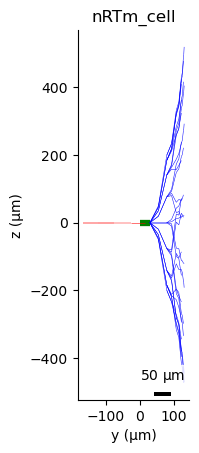

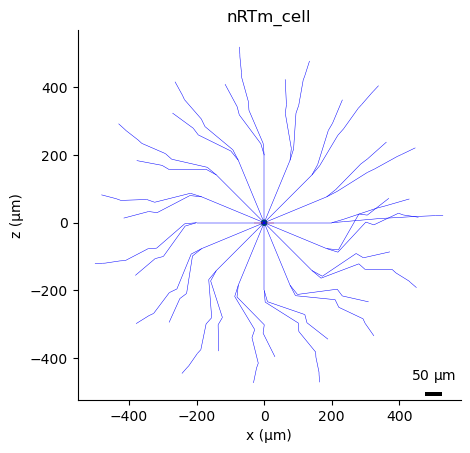

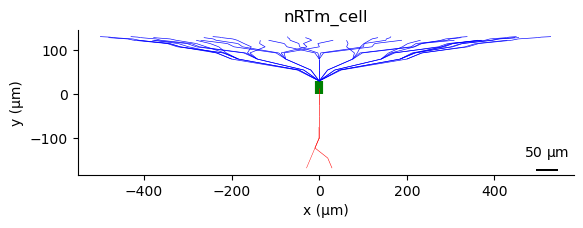

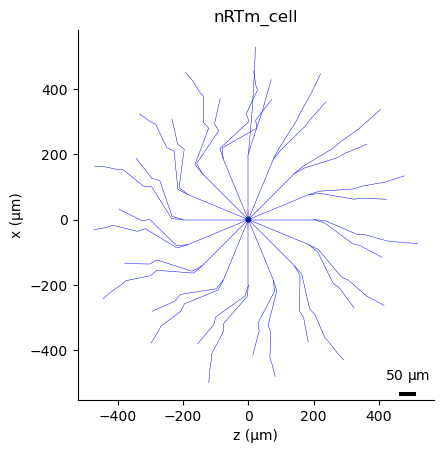

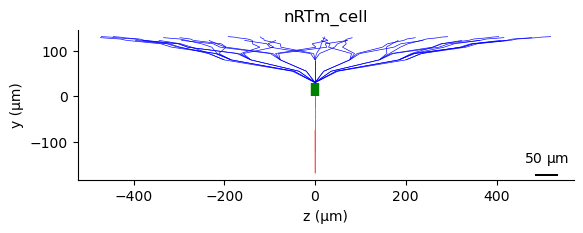

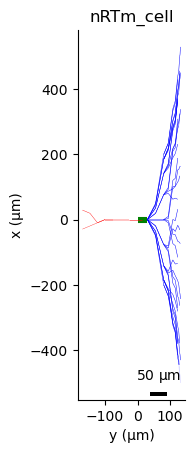

In [6]:
if __name__ == "__main__":
    main()